# <h1 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"><b>Kids Hobby Prediction Using Machine Learning </b></h1>
<center><img src="https://www.splashlearn.com/blog/wp-content/uploads/2023/08/kids-engaging-in-different-eca.jpeg" width="300" 
height="500"></center>

# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"> 1. Importing the packages </h3>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"> 2. Loading the dataset </h3> 

In [5]:
kids_data=pd.read_csv("Hobby_Data.csv")

#### Checking top 5 rows of the dataset

In [6]:
kids_data.head()

,Olympiad_Participation,Scholarship,School,Fav_sub,Projects,Grasp_pow,Time_sprt,Medals,Career_sprt,Act_sprt,Fant_arts,Won_arts,Time_art,Predicted Hobby
0,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
1,Yes,Yes,Yes,Mathematics,Yes,3,2,No,No,No,No,No,1,Academics
2,Yes,Yes,Yes,Science,Yes,5,1,Yes,No,No,No,No,1,Academics
3,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
4,Yes,Yes,Yes,Science,Yes,5,3,No,No,No,No,No,2,Academics


#### Checking the shape of the dataset

In [7]:
kids_data.shape

(1601, 14)

#### Viewing the datatypes of the dataset

In [8]:
kids_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Olympiad_Participation  1601 non-null   object
 1   Scholarship             1601 non-null   object
 2   School                  1601 non-null   object
 3   Fav_sub                 1601 non-null   object
 4   Projects                1601 non-null   object
 5   Grasp_pow               1601 non-null   int64 
 6   Time_sprt               1601 non-null   int64 
 7   Medals                  1601 non-null   object
 8   Career_sprt             1601 non-null   object
 9   Act_sprt                1601 non-null   object
 10  Fant_arts               1601 non-null   object
 11  Won_arts                1601 non-null   object
 12  Time_art                1601 non-null   int64 
 13  Predicted Hobby         1601 non-null   object
dtypes: int64(3), object(11)
memory usage: 175.2+ KB


#### Viewing the statistics of the data

In [9]:
kids_data.describe()

,Grasp_pow,Time_sprt,Time_art
count,1601.000000,1601.000000,1601.000000
mean,3.480325,3.033729,2.234229
std,1.006737,1.347725,1.266186
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000
50%,3.000000,3.000000,2.000000
75%,4.000000,4.000000,3.000000
max,6.000000,6.000000,6.000000


# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"> 3. Data Preprocessing </h3> 

### 1. Data Cleaning

#### a. Checking the null values

In [10]:
kids_data.isnull().sum()

Olympiad_Participation    0
Scholarship               0
School                    0
Fav_sub                   0
Projects                  0
Grasp_pow                 0
Time_sprt                 0
Medals                    0
Career_sprt               0
Act_sprt                  0
Fant_arts                 0
Won_arts                  0
Time_art                  0
Predicted Hobby           0
dtype: int64

> Since there are no null values we can proceed further.

#### b. Renaming the columns

In [11]:
kids_data.rename(columns = {'Scholarship':'received_scholarship','School':'Love\'s going to school','Projects':'projects under academics','Grasp_pow':'Grasping power','Time_sprt':'playing outdoor/indoor','Medals':'Medals won in Sports','Career_sprt':'pursue career in sports','Act_sprt':'Regular sports activities','Fant_arts':'fantasy paintings','Won_arts':'Won art competitions','Time_art':'Time utilized in Arts'}, inplace = True)

In [12]:
kids_data

,Olympiad_Participation,received_scholarship,Love's going to school,Fav_sub,projects under academics,Grasping power,playing outdoor/indoor,Medals won in Sports,pursue career in sports,Regular sports activities,fantasy paintings,Won art competitions,Time utilized in Arts,Predicted Hobby
0,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
1,Yes,Yes,Yes,Mathematics,Yes,3,2,No,No,No,No,No,1,Academics
2,Yes,Yes,Yes,Science,Yes,5,1,Yes,No,No,No,No,1,Academics
3,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
4,Yes,Yes,Yes,Science,Yes,5,3,No,No,No,No,No,2,Academics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,No,No,Yes,Science,No,3,1,Yes,Yes,Yes,No,No,2,Sports
1597,Yes,No,Yes,Any language,Yes,4,3,No,Yes,No,No,Yes,4,Sports
1598,Yes,No,Yes,Any language,No,3,3,No,Yes,No,No,Maybe,2,Sports
1599,Yes,Yes,Yes,Any language,No,4,3,Yes,Yes,No,Yes,Maybe,2,Sports


### Label Encoding

In [13]:
kids_data.replace({'Olympiad_Participation':{'No':0,'Yes':1}
                 ,'received_scholarship':{'No':0,'Yes':1}
                 ,'Love\'s going to school':{'No':0,'Yes':1}
                 ,'Fav_sub':{'Any language':0,'History/Geography':1,'Mathematics':2,'Science':3}
                 ,'projects under academics':{'No':0,'Yes':1}
                 ,'Medals won in Sports':{'No':0,'Yes':1}
                 ,'pursue career in sports':{'No':0,'Yes':1}
                 ,'Regular sports activities':{'No':0,'Yes':1}
                 ,'fantasy paintings':{'No':0,'Yes':1}
                 ,'Won art competitions':{'No':0,'Yes':1,'Maybe':2}
                 ,'Predicted Hobby':{'Academics':0,'Arts':1,'Sports':2}},inplace=True)

# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"> 4. Splitting of Dataset </h3>  

In [14]:
X = kids_data.drop(columns=['Predicted Hobby'],axis=1)
Y = kids_data['Predicted Hobby']

In [15]:
print(X.head())

   Olympiad_Participation  received_scholarship  Love's going to school  \
0                       1                     1                       1   
1                       1                     1                       1   
2                       1                     1                       1   
3                       1                     1                       1   
4                       1                     1                       1   

   Fav_sub  projects under academics  Grasping power  playing outdoor/indoor  \
0        2                         1               5                       1   
1        2                         1               3                       2   
2        3                         1               5                       1   
3        2                         1               5                       1   
4        3                         1               5                       3   

   Medals won in Sports  pursue career in sports  Regular sports act

In [16]:
print(Y.head())

0    0
1    0
2    0
3    0
4    0
Name: Predicted Hobby, dtype: int64


In [17]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,stratify=Y,test_size=0.2,random_state=0)

In [18]:
print(X_test.head())

      Olympiad_Participation  received_scholarship  Love's going to school  \
551                        0                     0                       0   
906                        0                     0                       0   
746                        0                     0                       1   
633                        1                     0                       1   
1446                       0                     0                       0   

      Fav_sub  projects under academics  Grasping power  \
551         0                         0               4   
906         0                         1               4   
746         1                         1               3   
633         3                         1               3   
1446        2                         1               3   

      playing outdoor/indoor  Medals won in Sports  pursue career in sports  \
551                        2                     1                        0   
906               

In [19]:
print(Y_test.head())

551     0
906     1
746     1
633     0
1446    2
Name: Predicted Hobby, dtype: int64


In [20]:
print(X.shape, X_train.shape, X_test.shape)

(1601, 13) (1280, 13) (321, 13)


# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;"> 5. Building of Machine Learning Models </h3>  

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [22]:
pipe_log_reg=Pipeline([("log_reg_classifier",LogisticRegression(random_state=0))])

pipe_ada=Pipeline([("ada_classifier",AdaBoostClassifier(n_estimators=100, random_state=42))])

pipe_dt=Pipeline([("dt_classifier", DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0))])

pipe_gau_nb=Pipeline([("gau_nb_classifier",GaussianNB())])

pipe_rf=Pipeline([("rf_classifier",RandomForestClassifier(n_estimators=100, random_state=42))])

pipe_svc=Pipeline([("svc_classifier",SVC(kernel='poly',C=10, gamma='scale'))])

In [23]:
pipelines=[pipe_log_reg,pipe_ada,pipe_dt,pipe_gau_nb,pipe_rf,pipe_svc]
model_names=["Logistic Regression","ADA Boost Classifier","DecisionTree Classifier","GaussianNB","RandomForestClassifier","Support Vector Classifier"]

In [24]:
for pipe in pipelines:
    pipe.fit(X_train, Y_train)

In [25]:
score=[]
def model_eval(model_name):
    i=0
    global score
    for pipe in pipelines:
        print(f"Model: {model_name[i]}\n")
        pred = pipe.predict(X_test)

        accuracy = accuracy_score(Y_test, pred)
        classification_rep = classification_report(Y_test, pred)
        conf_matrix = confusion_matrix(Y_test, pred)
        score.append(accuracy)

        print(f"Accuracy of {model_name[i]}")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)
        print("\nClassification Report:\n", classification_rep)
        print("------------------------------------------------------")
        i+=1

# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;">   6. Model Evaluation </h3>

In [26]:
model_eval(model_names)

Model: Logistic Regression

Accuracy of Logistic Regression
Accuracy: 0.8816

Confusion Matrix:
 [[122   8  10]
 [  7  71   4]
 [  7   2  90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       140
           1       0.88      0.87      0.87        82
           2       0.87      0.91      0.89        99

    accuracy                           0.88       321
   macro avg       0.88      0.88      0.88       321
weighted avg       0.88      0.88      0.88       321

------------------------------------------------------
Model: ADA Boost Classifier

Accuracy of ADA Boost Classifier
Accuracy: 0.8910

Confusion Matrix:
 [[126   3  11]
 [  7  71   4]
 [  8   2  89]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       140
           1       0.93      0.87      0.90        82
           2       0.86      0.90      0.88        99

    accu

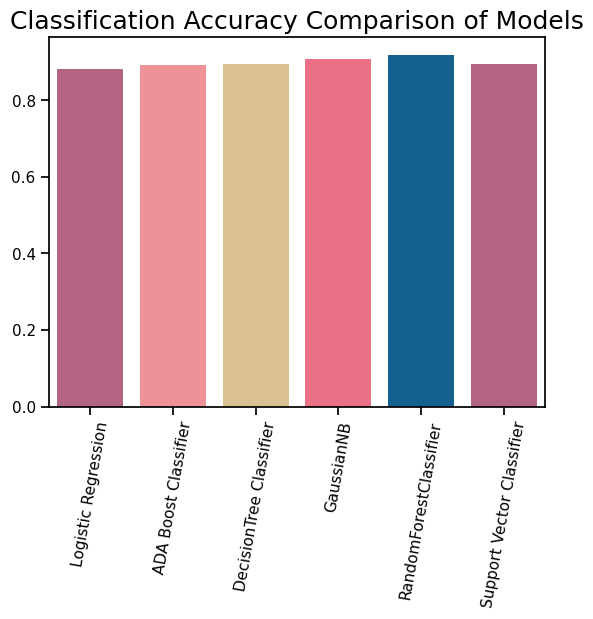

In [27]:
sns.set(context='notebook', style=None)
ax = sns.barplot(x=model_names, y=score, palette=['#C05780','#FF828B','#E7C582','#FF5C77','#0065A2'])
ax.set_title('Classification Accuracy Comparison of Models', fontsize=18)
for item in ax.get_xticklabels():
    item.set_rotation(80)
for p in ax.patches:
        ax.annotate('{:}%'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+1))

# <h3 style="text-align: center; background-color: skyblue; color: maroon; padding: 20px; border-radius: 5px;">   8. Model Prediction </h3>

In [28]:
model=RandomForestClassifier(n_estimators=100, random_state=42)

In [29]:
model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [30]:
X_test

,Olympiad_Participation,received_scholarship,Love's going to school,Fav_sub,projects under academics,Grasping power,playing outdoor/indoor,Medals won in Sports,pursue career in sports,Regular sports activities,fantasy paintings,Won art competitions,Time utilized in Arts
551,0,0,0,0,0,4,2,1,0,1,1,0,2
906,0,0,0,0,1,4,2,0,0,0,1,1,1
746,0,0,1,1,1,3,2,1,0,1,1,1,4
633,1,0,1,3,1,3,5,0,0,0,0,0,1
1446,0,0,0,2,1,3,2,0,1,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,1,1,1,1,0,4,1,0,0,0,0,0,1
951,0,0,0,2,0,4,1,0,0,1,1,0,3
783,0,0,1,2,1,3,1,1,0,1,1,1,5
139,1,1,1,2,1,5,2,0,0,0,1,2,1


In [31]:
Y_test

551     0
906     1
746     1
633     0
1446    2
       ..
256     0
951     1
783     1
139     0
1344    2
Name: Predicted Hobby, Length: 321, dtype: int64

In [32]:
#making a predictive system
input_data=(1,0,1,3,1,3,5,0,0,0,0,0,1)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Hobby Predicted as Academics")
elif(prediction[0]==1):
    print("Hobby Predicted as Arts")
elif(prediction[0]==2):
    print("Hobby Predicted as Sports")

[0]
Hobby Predicted as Academics


In [33]:
#making a predictive system
input_data=(0,0,1,1,1,3,2,1,0,1,1,1,4)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Hobby Predicted as Academics")
elif(prediction[0]==1):
    print("Hobby Predicted as Arts")
elif(prediction[0]==2):
    print("Hobby Predicted as Sports")

[1]
Hobby Predicted as Arts


In [34]:
#making a predictive system
input_data=(0,0,0,2,0,2,4,1,1,1,0,0,2)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Hobby Predicted as Academics")
elif(prediction[0]==1):
    print("Hobby Predicted as Arts")
elif(prediction[0]==2):
    print("Hobby Predicted as Sports")

[2]
Hobby Predicted as Sports


In [35]:
import pickle

filename = 'kid_hobby.pkl'
pickle.dump(model,open(filename,'wb'))